In [1]:
# Regular EDA and plotting libraries
import numpy as np  #tableaux et matrices
import pandas as pd # Permet de manipuler et d'analyser des données sous forme de dataframes, ce qui est similaire à des tableaux Excel
import matplotlib.pyplot as plt  #Permet de créer des visualisations de données, comme des graphiques et des diagrammes.
import seaborn as sns #  Permet de créer des visualisations de données plus complexes et plus attrayantes que celles fournies par matplotlib.

# We want our plots to appear in the notebook
# Afin de visualiser les graphiques dans le notebook
%matplotlib inline 

# Configuration pour éviter les warnings de dépréciation de pandas
pd.set_option('future.no_silent_downcasting', True)

# Importation des métriques pour la régression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Models pour la régression
from sklearn.linear_model import LinearRegression #implémenter le modèle de régression linéaire
from sklearn.neighbors import KNeighborsRegressor # pour implémenter le modèle de plus proches voisins (KNN) pour la régression
from sklearn.ensemble import RandomForestRegressor #implémenter le modèle de forêt d'arbres aléatoires (Random Forest) pour la régression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score #utilisés pour diviser les données en ensembles d'entraînement et de test, et pour évaluer les modèles à l'aide de la validation croisée.
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV #pour ajuster les hyperparamètres des modèles.

# Print last updated
import time
print(f"Last updated: {time.asctime()}")

Last updated: Tue Apr 14 18:55:08 2026


In [2]:
df = pd.read_csv("../data/real_estate_processed.csv") # 'DataFrame' shortened to 'df'  # charger le jeu de données traité
df.shape # (rows, columns)  # afficher sa taille

(5653, 12)

In [3]:
#Exploration initiale du jeu de données
df.head(10)  # Affiche les 5 premières lignes du DataFrame

,title,price_text,price,category,city,location,type_transaction,rooms,post_time,post_date,post_month,post_year
0,À louer – Bureaux neufs S+1 et S+2 à Monastir ...,650 DT,650,0,Monastir,Monastir,0,1,2/4/26 12:37,02-04-26,2,2026
1,S+1 haut standing pour la saison universitaire,850 DT,850,0,Monastir,Monastir,0,1,8/30/25 10:49,08-30-25,8,2025
2,à vendre s+3 haut standing directement au prom...,350000 DT,350000,1,Monastir,Bekalta,1,3,7/30/25 12:45,07-30-25,7,2025
3,Appartement s+1 vue sur mer pour vacance d’été...,1540 DT,1540,2,Monastir,Bekalta,0,1,6/17/25 9:41,06-17-25,6,2025
4,Studio mignon estivale,55 DT,55,0,Monastir,Monastir,0,0,6/10/25 20:59,06-10-25,6,2025
5,S+2 à louer pour longue durée,550 DT,550,0,Monastir,Monastir,0,2,5/26/25 14:58,05-26-25,5,2025
6,A vendre S+1 lumineux à Folla Monastir,430000 DT,430000,1,Monastir,Monastir,1,1,5/21/25 10:18,05-21-25,5,2025
7,À vendre Superbe S+1 à Folla Monastir,400000 DT,400000,1,Monastir,Monastir,1,1,5/21/25 9:51,05-21-25,5,2025
8,À vendre Superbe S+1 sur mer à Folla Monastir,430000 DT,430000,1,Monastir,Monastir,1,1,5/13/25 11:02,05-13-25,5,2025
9,À vendre – Superbe S+1 à Folla Monastir,400000 DT,400000,1,Monastir,Monastir,1,1,5/10/25 11:23,05-10-25,5,2025


In [4]:
df.describe()  # Donne des statistiques descriptives

,price,category,type_transaction,post_month,post_year
count,5.653000e+03,5653.000000,5653.000000,5653.000000,5653.000000
mean,2.602782e+05,1.337697,0.425615,5.818857,2025.185919
std,3.889321e+06,1.461849,0.494480,3.604828,0.389076
min,0.000000e+00,0.000000,0.000000,1.000000,2025.000000
25%,1.350000e+03,0.000000,0.000000,2.000000,2025.000000
50%,3.500000e+03,1.000000,0.000000,5.000000,2025.000000
75%,2.800000e+05,3.000000,1.000000,9.000000,2025.000000
max,2.100000e+08,4.000000,1.000000,12.000000,2026.000000


In [5]:
df.info()  # Affiche les informations sur les colonnes et les types de données

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5653 entries, 0 to 5652
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             5653 non-null   object
 1   price_text        5653 non-null   object
 2   price             5653 non-null   int64 
 3   category          5653 non-null   int64 
 4   city              5653 non-null   object
 5   location          5653 non-null   object
 6   type_transaction  5653 non-null   int64 
 7   rooms             5653 non-null   object
 8   post_time         5653 non-null   object
 9   post_date         5653 non-null   object
 10  post_month        5653 non-null   int64 
 11  post_year         5653 non-null   int64 
dtypes: int64(5), object(7)
memory usage: 530.1+ KB


In [6]:
df.dtypes  # Donne le type de données de chaque colonne

title               object
price_text          object
price                int64
category             int64
city                object
location            object
type_transaction     int64
rooms               object
post_time           object
post_date           object
post_month           int64
post_year            int64
dtype: object

In [7]:
#Afficher la somme des valeurs manquantes
df.isnull().sum()

title               0
price_text          0
price               0
category            0
city                0
location            0
type_transaction    0
rooms               0
post_time           0
post_date           0
post_month          0
post_year           0
dtype: int64

In [8]:
# Vérifier les doublons
duplicate_rows = df[df.duplicated()]
print("Nombre de lignes dupliquées:", duplicate_rows.shape[0])


Nombre de lignes dupliquées: 21


In [9]:
# Let's see how many location (0) and vente (1) samples we have in our dataframe
df.type_transaction.value_counts()  #compter le nombre d'occurrences de chaque type de transaction

type_transaction
0    3247
1    2406
Name: count, dtype: int64

In [10]:
# Normalized value counts
df.type_transaction.value_counts(normalize=True)  #permet d'obtenir le nombre d'occurrences de chaque valeur unique dans une série ou une colonne de données

type_transaction
0    0.574385
1    0.425615
Name: proportion, dtype: float64

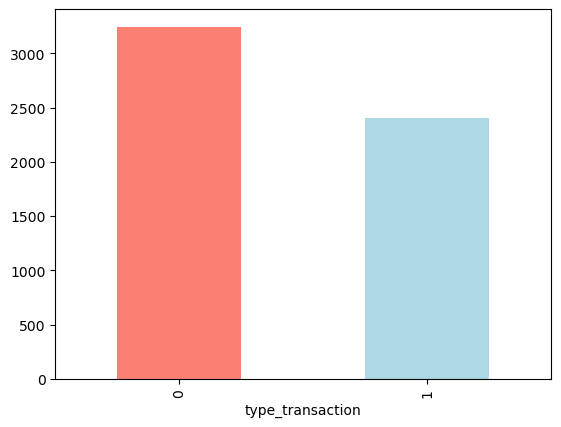

In [11]:
# Plot value counts with a bar graph
df.type_transaction.value_counts().plot(kind="bar", color=["salmon", "lightblue"]); #Pour tracer les valeurs comptées avec un graphique en barres des types de transaction

In [12]:
df.category.value_counts()  #Pour compter le nombre d'occurrences de chaque catégorie

category
0    2341
1    1431
3     975
4     697
2     209
Name: count, dtype: int64

In [13]:
# Compare type_transaction column with category column
pd.crosstab(df.type_transaction, df.category)
#comparer les types de transaction par catégorie

category,0,1,2,3,4
type_transaction,,,,,
0,2341,0,209,0,697
1,0,1431,0,975,0


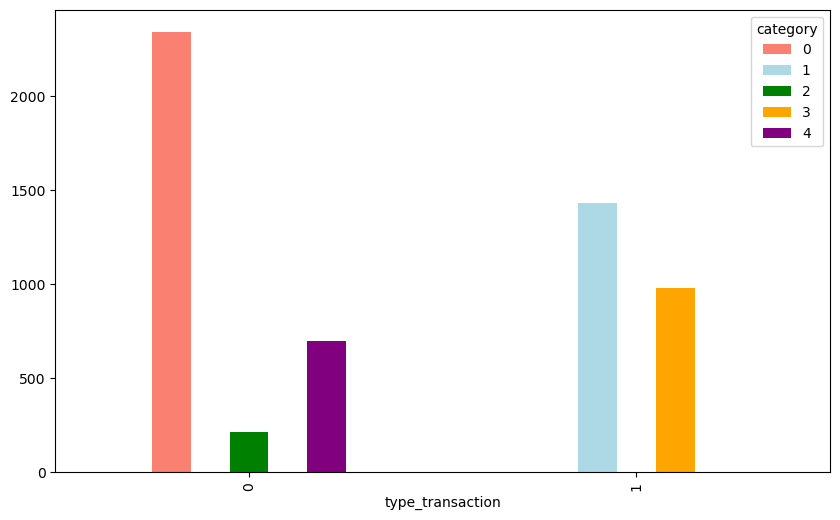

In [14]:
# Create a plot
pd.crosstab(df.type_transaction, df.category).plot(kind="bar", 
                                    figsize=(10,6), 
                                    color=["salmon", "lightblue", "green", "orange", "purple"]);

#tracer la séparation dans un graphe

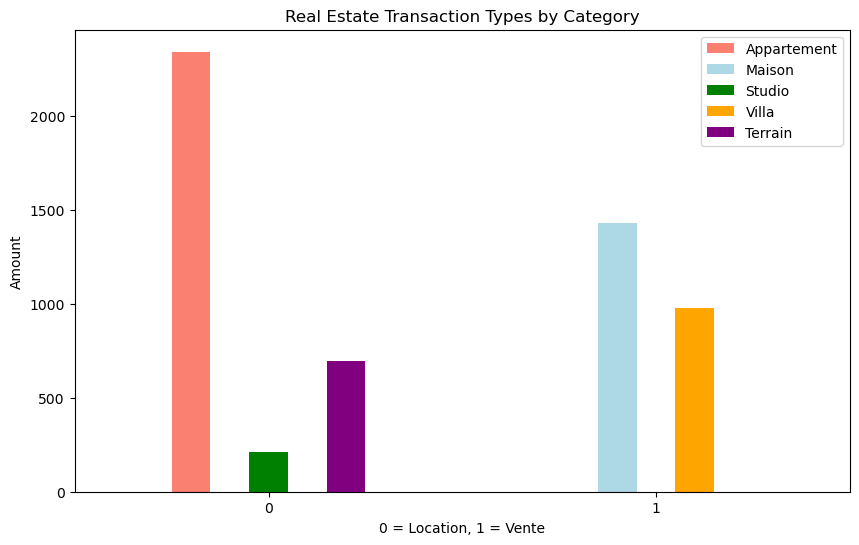

In [15]:
# Create a plot
pd.crosstab(df.type_transaction, df.category).plot(kind="bar", figsize=(10,6), color=["salmon", "lightblue", "green", "orange", "purple"])

# Add some attributes to it
plt.title("Real Estate Transaction Types by Category")
plt.xlabel("0 = Location, 1 = Vente")
plt.ylabel("Amount")
plt.legend(["Appartement", "Maison", "Studio", "Villa", "Terrain"])
plt.xticks(rotation=0); # keep the labels on the x-axis vertical

#crée un graphique de barres montrant les types de transactions immobilières par catégorie.

In [67]:
# Vérifier les colonnes disponibles
print("Colonnes disponibles dans le DataFrame:")
print(df.columns.tolist())

# Afficher les types de données
print("\nTypes de données:")
print(df.dtypes)

#affiche les colonnes et types de données disponibles

Colonnes disponibles dans le DataFrame:
['title', 'price_text', 'price', 'category', 'city', 'location', 'type_transaction', 'rooms', 'post_time', 'post_date', 'post_month', 'post_year']

Types de données:
title               object
price_text          object
price                int64
category             int64
city                object
location            object
type_transaction     int64
rooms               object
post_time           object
post_date           object
post_month           int64
post_year            int64
dtype: object


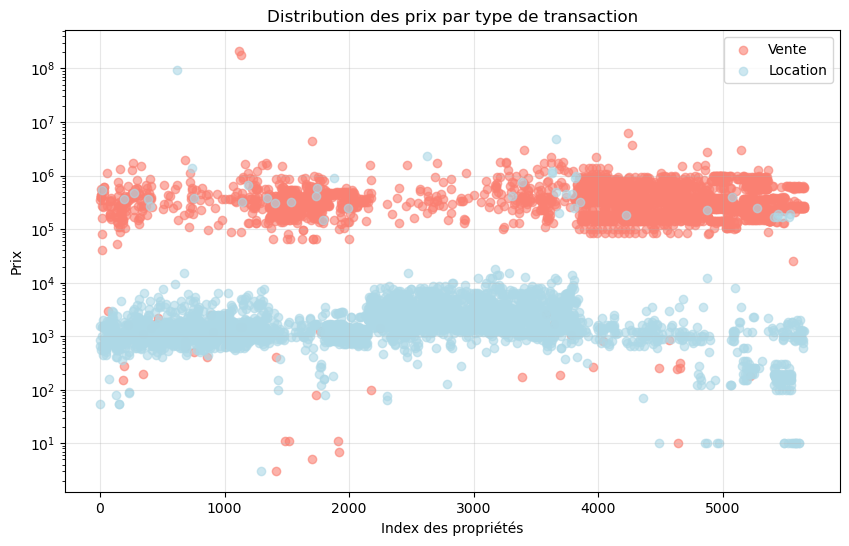

In [68]:
# Analyse des prix par type de transaction
plt.figure(figsize=(10,6))

# Vente (1)
plt.scatter(
    df[df.type_transaction == 1].index,
    df.price[df.type_transaction == 1],
    c="salmon",
    label="Vente",
    alpha=0.6
)

# Location (0)
plt.scatter(
    df[df.type_transaction == 0].index,
    df.price[df.type_transaction == 0],
    c="lightblue",
    label="Location",
    alpha=0.6
)

# Infos
plt.title("Distribution des prix par type de transaction")
plt.xlabel("Index des propriétés")
plt.ylabel("Prix")
plt.legend()
plt.yscale('log')  # Échelle log pour mieux voir la distribution
plt.grid(True, alpha=0.3)
plt.show()

#crée un graphique de dispersion montrant la distribution des prix par type de transaction

In [69]:
# Matrice de corrélation pour les variables numériques uniquement
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Colonnes numériques:", numeric_cols.tolist())

corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

#trouver la corrélation entre les variables numériques

Colonnes numériques: ['price', 'category', 'type_transaction', 'post_month', 'post_year']
                     price  category  type_transaction  post_month  post_year
price             1.000000  0.024541          0.066281    0.000008  -0.008094
category          0.024541  1.000000          0.278419    0.051631   0.011224
type_transaction  0.066281  0.278419          1.000000    0.004350   0.055802
post_month        0.000008  0.051631          0.004350    1.000000  -0.538350
post_year        -0.008094  0.011224          0.055802   -0.538350   1.000000


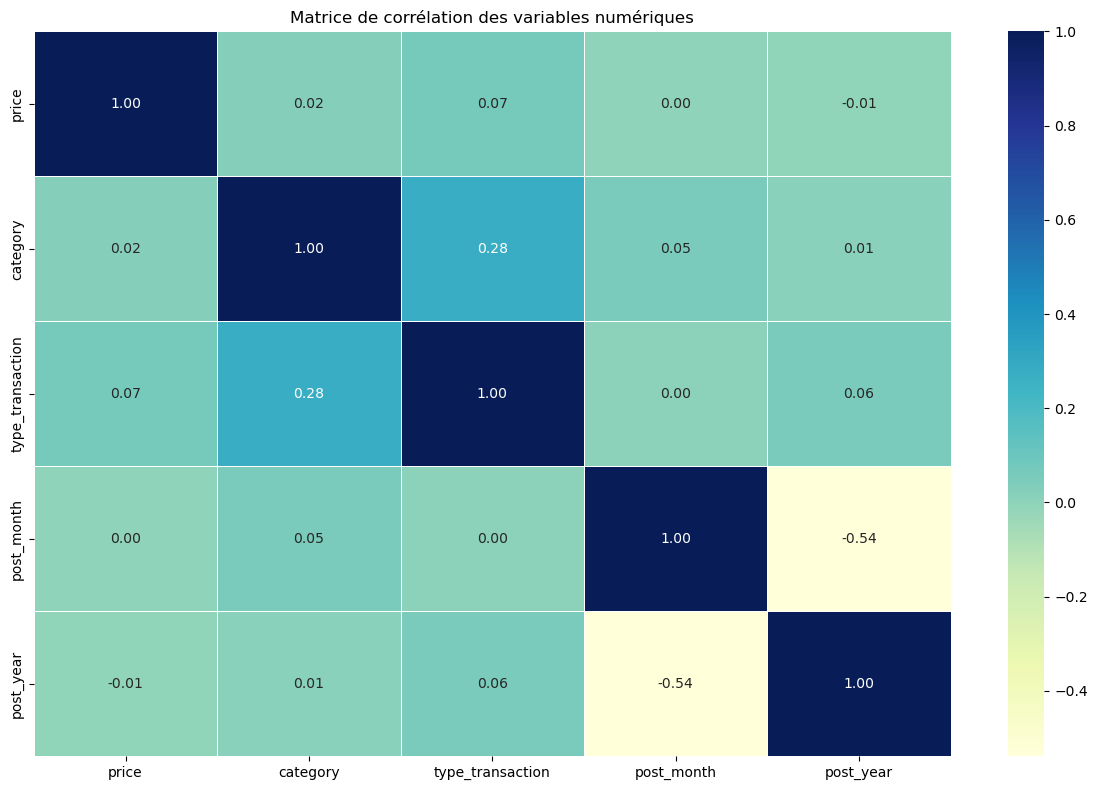

In [70]:
# Heatmap de la matrice de corrélation
fig, ax = plt.subplots(figsize=(12, 8))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt=".2f",
                 cmap="YlGnBu")
plt.title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()

#rendre la matrice de corrélation plus visuelle avec une carte de chaleur

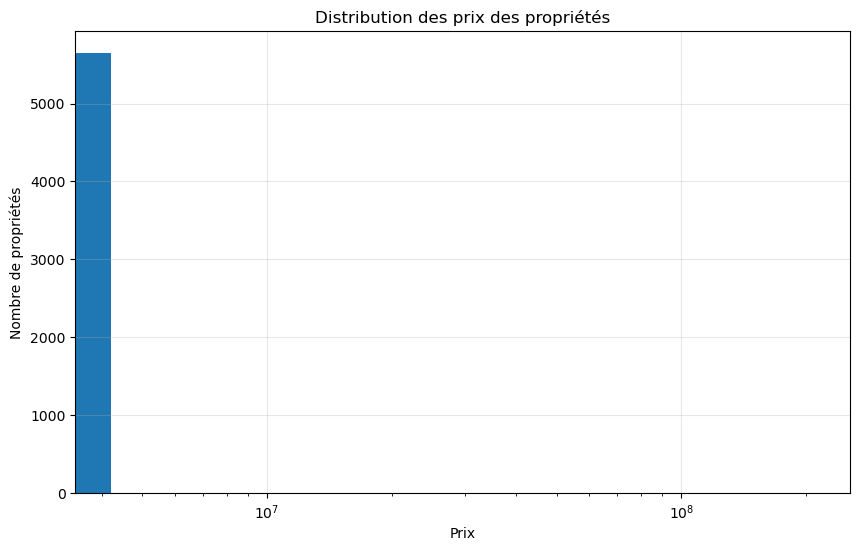

In [71]:
# Distribution des prix
df.price.hist(bins=50, figsize=(10,6))
plt.xlabel('Prix')
plt.ylabel('Nombre de propriétés')
plt.title('Distribution des prix des propriétés')
plt.xscale('log')  # Échelle log pour mieux voir la distribution
plt.grid(True, alpha=0.3)
plt.show()

#affiche l'histogramme de la distribution des prix des propriétés

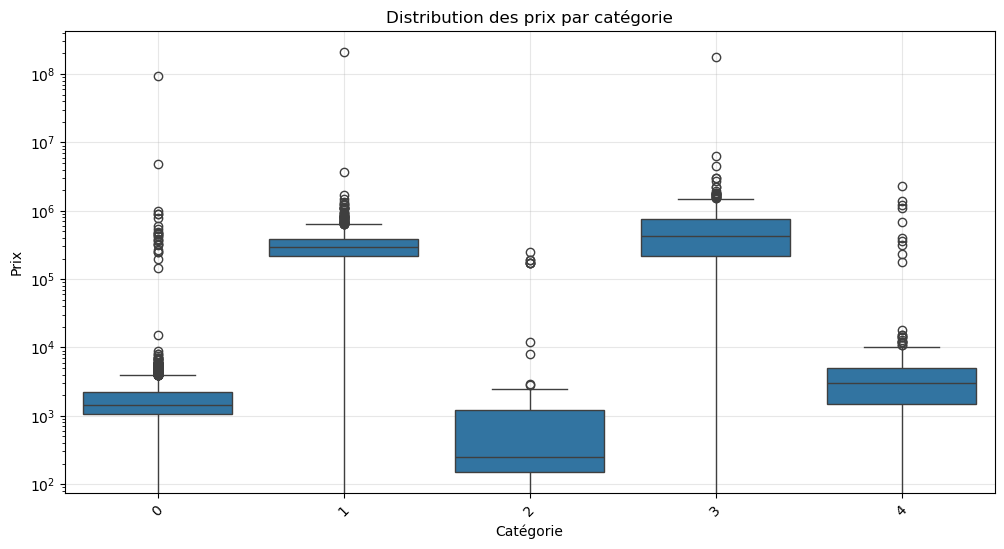

In [72]:
# Boxplot des prix par catégorie
plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='price', data=df)
plt.title('Distribution des prix par catégorie')
plt.xlabel('Catégorie')
plt.ylabel('Prix')
plt.yscale('log')  # Échelle log pour mieux voir la distribution
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

#crée un boxplot montrant la distribution des prix par catégorie

Prix moyen par ville:
city
Ariana       494291.182218
Nabeul       328090.829694
Monastir     278446.562500
Medenine     255833.333333
Sousse       200295.287327
Manouba      189019.230769
Ben arous    172672.096774
Tunis         73431.709156
Mahdia        71136.893204
Sfax          70250.000000
Bizerte       29445.333333
Kairouan        450.000000
Name: price, dtype: float64


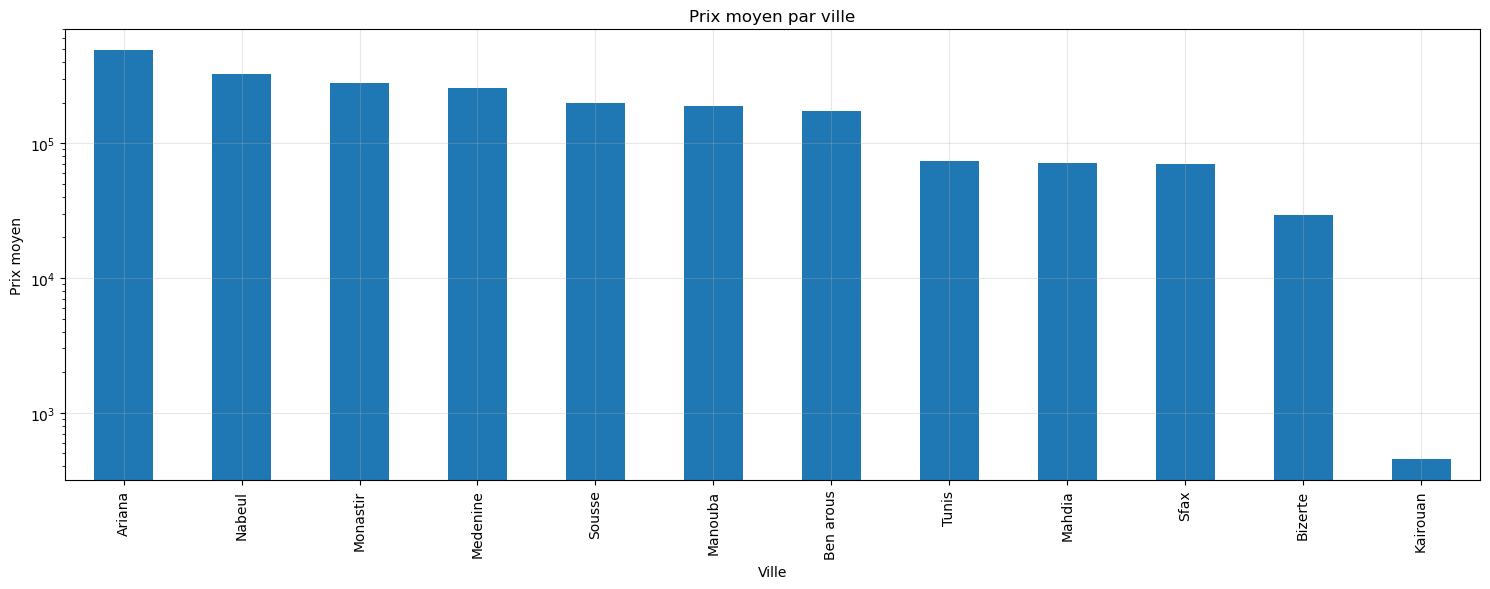

In [73]:
# Prix moyen par ville
prix_par_ville = df.groupby('city')['price'].mean().sort_values(ascending=False)
print("Prix moyen par ville:")
print(prix_par_ville)

# Visualisation
prix_par_ville.plot(kind='bar', figsize=(15, 6))
plt.title('Prix moyen par ville')
plt.xlabel('Ville')
plt.ylabel('Prix moyen')
plt.yscale('log')  # Échelle log pour mieux voir les différences
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

#calcule et affiche le prix moyen par ville

Valeurs uniques de 'rooms':
['1' '3' '0' '2' '4' '6' '5' 'S+9' '8' 'S+25' 'S+11' '7']

Nombre de propriétés par nombre de pièces:
rooms
0        249
1       1142
2       2041
3       1373
4        583
5        228
6         26
7          4
8          2
S+11       1
S+25       1
S+9        3
Name: count, dtype: int64


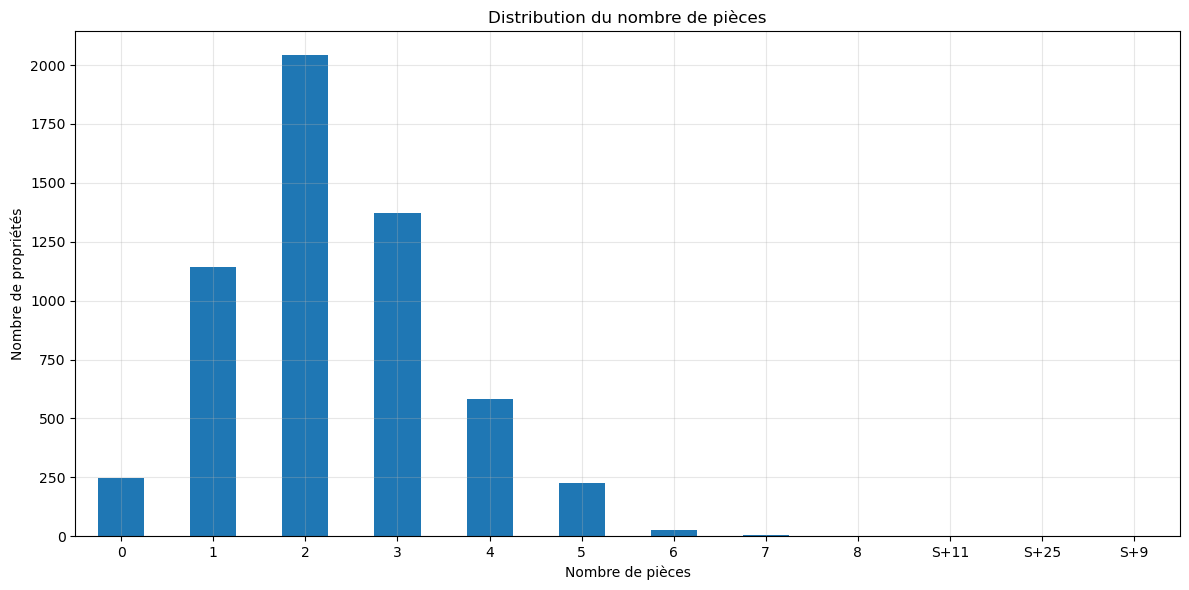

In [74]:
# Distribution du nombre de pièces (rooms)
# Convertir rooms en numérique si possible
print("Valeurs uniques de 'rooms':")
print(df['rooms'].unique())

# Analyse des rooms
room_counts = df['rooms'].value_counts().sort_index()
print("\nNombre de propriétés par nombre de pièces:")
print(room_counts)

# Visualisation
plt.figure(figsize=(12, 6))
room_counts.plot(kind='bar')
plt.title('Distribution du nombre de pièces')
plt.xlabel('Nombre de pièces')
plt.ylabel('Nombre de propriétés')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#analyse la distribution du nombre de pièces

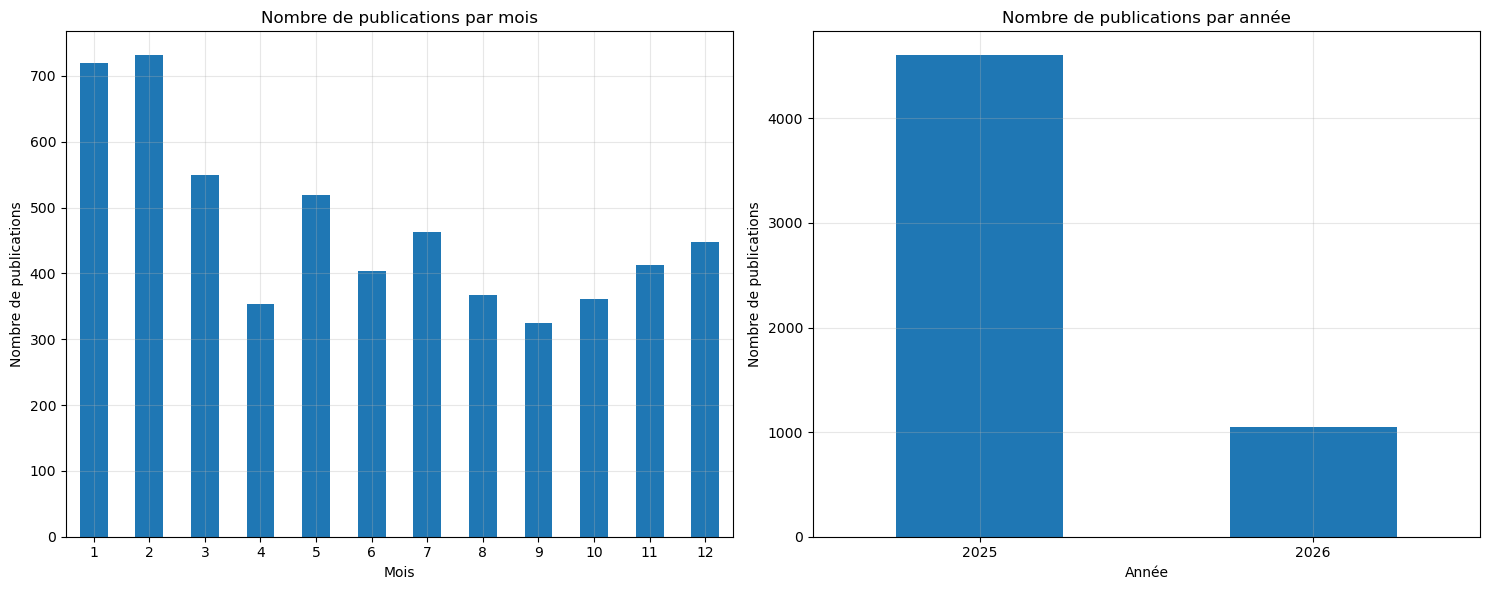

In [75]:
# Analyse temporelle des publications
plt.figure(figsize=(15, 6))

# Par mois
plt.subplot(1, 2, 1)
df['post_month'].value_counts().sort_index().plot(kind='bar')
plt.title('Nombre de publications par mois')
plt.xlabel('Mois')
plt.ylabel('Nombre de publications')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)

# Par année
plt.subplot(1, 2, 2)
df['post_year'].value_counts().sort_index().plot(kind='bar')
plt.title('Nombre de publications par année')
plt.xlabel('Année')
plt.ylabel('Nombre de publications')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#analyse la distribution temporelle des publications

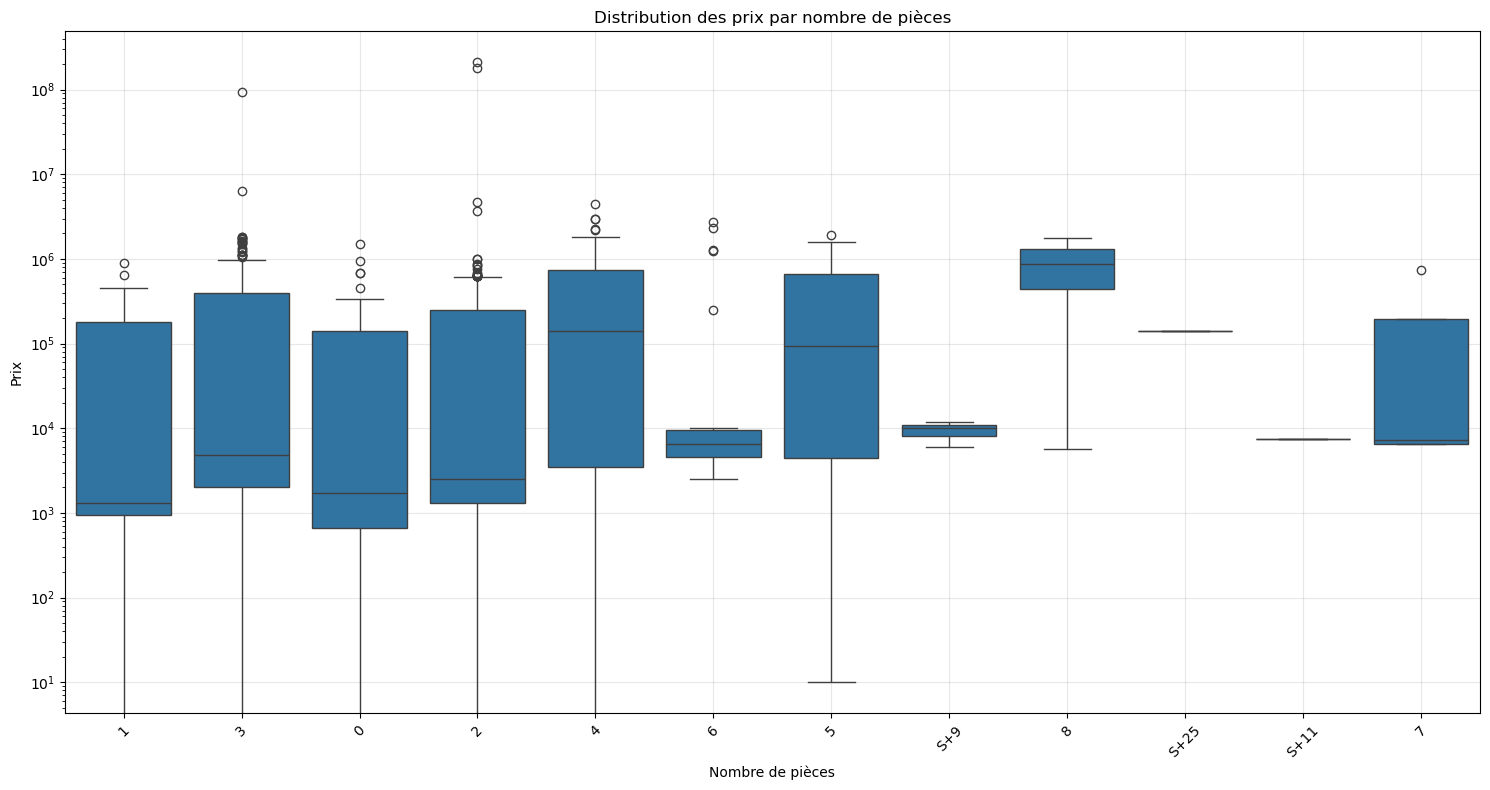

In [76]:
# Analyse des prix par nombre de pièces
plt.figure(figsize=(15, 8))
sns.boxplot(x='rooms', y='price', data=df)
plt.title('Distribution des prix par nombre de pièces')
plt.xlabel('Nombre de pièces')
plt.ylabel('Prix')
plt.yscale('log')  # Échelle log pour mieux voir la distribution
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#affiche la distribution des prix par nombre de pièces

Statistiques des prix par catégorie :
                   mean    median  count           std
category                                              
3         700045.688205  420000.0    975  5.764308e+06
1         464114.328442  298000.0   1431  5.546340e+06
0          48128.324220    1450.0   2341  1.930896e+06
4          15121.938307    3000.0    697  1.235522e+05
2           6948.133971     250.0    209  3.400883e+04


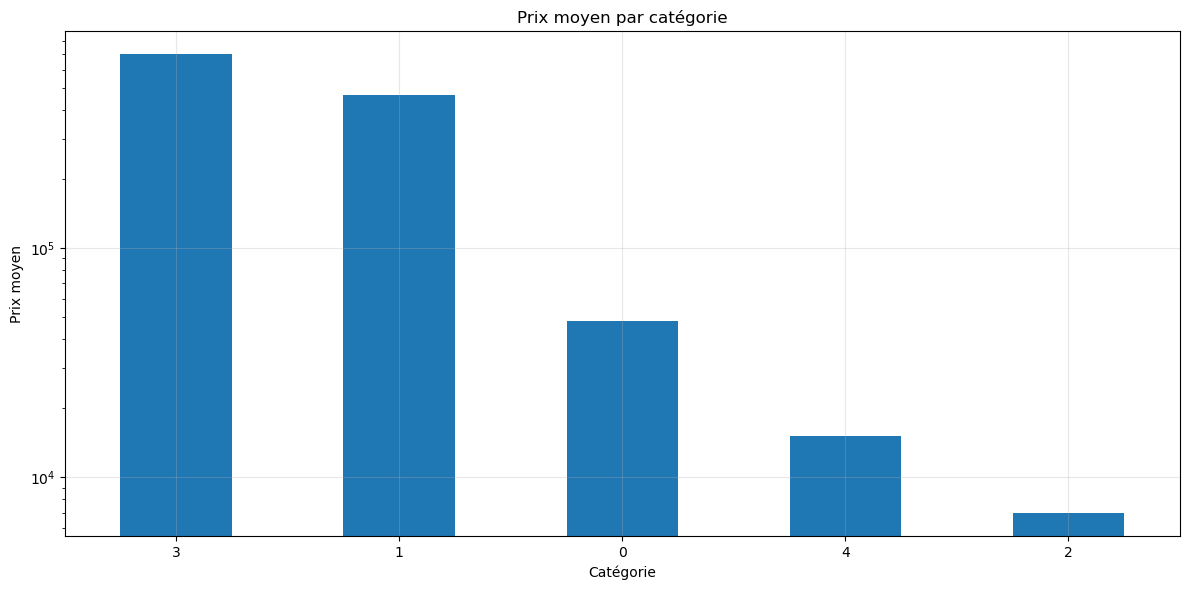

In [77]:
# Prix moyen par catégorie
prix_moyen_categorie = df.groupby('category')['price'].agg(['mean', 'median', 'count', 'std']).sort_values('mean', ascending=False)
print("Statistiques des prix par catégorie :")
print(prix_moyen_categorie.to_string())

# Visualisation
plt.figure(figsize=(12, 6))
prix_moyen_categorie['mean'].plot(kind='bar')
plt.title('Prix moyen par catégorie')
plt.xlabel('Catégorie')
plt.ylabel('Prix moyen')
plt.yscale('log')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#affiche les statistiques des prix par catégorie

In [78]:
# Analyse des outliers dans les prix
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Nombre d'outliers dans les prix: {len(outliers)}")
print(f"Pourcentage d'outliers: {len(outliers)/len(df)*100:.2f}%")

print("\nStatistiques des prix:")
print(f"Prix minimum: {df['price'].min():.0f}")
print(f"Prix maximum: {df['price'].max():.0f}")
print(f"Prix médian: {df['price'].median():.0f}")
print(f"Prix moyen: {df['price'].mean():.0f}")
print(f"Q1 (25%): {Q1:.0f}")
print(f"Q3 (75%): {Q3:.0f}")

#affiche les statistiques des prix et les outliers

Nombre d'outliers dans les prix: 303
Pourcentage d'outliers: 5.36%

Statistiques des prix:
Prix minimum: 0
Prix maximum: 210000000
Prix médian: 3500
Prix moyen: 260278
Q1 (25%): 1350
Q3 (75%): 280000


In [79]:
# Top 10 des propriétés les plus chères
top_10_cheres = df.nlargest(10, 'price')[['title', 'price', 'category', 'city', 'location', 'type_transaction']]
print("Top 10 des propriétés les plus chères:")
print(top_10_cheres.to_string())

# Top 10 des propriétés les moins chères (excluant les prix à 0)
top_10_moins_cheres = df[df['price'] > 0].nsmallest(10, 'price')[['title', 'price', 'category', 'city', 'location', 'type_transaction']]
print("\nTop 10 des propriétés les moins chères:")
print(top_10_moins_cheres.to_string())

#affiche les propriétés avec les prix extrêmes

Top 10 des propriétés les plus chères:
                                                             title      price  category    city            location  type_transaction
1117                          À Vendre | Appartement S+2 à Manar 1  210000000         1  Ariana              Ennasr                 1
1129                                                     villa s+2  180000000         3  Ariana              Ennasr                 1
615                                                  s+3 a manar 2   93279899         0  Ariana               Manar                 0
4236      Une villa S+3 toute neuve à vendre à AFH Mrezga 51355351    6300000         3  Nabeul              Mrezga                 1
3658               Appartement S+2 aux Jardins de Carthage MAV1827    4750000         0   Tunis  Jardin De Carthage                 0
1700    🔑VILLA S4 HAUT STANDING,Kantaoui–Vue Mer, Piscine & jardin    4500000         3  Sousse            Kantaoui                 1
4266      Bel apparteme

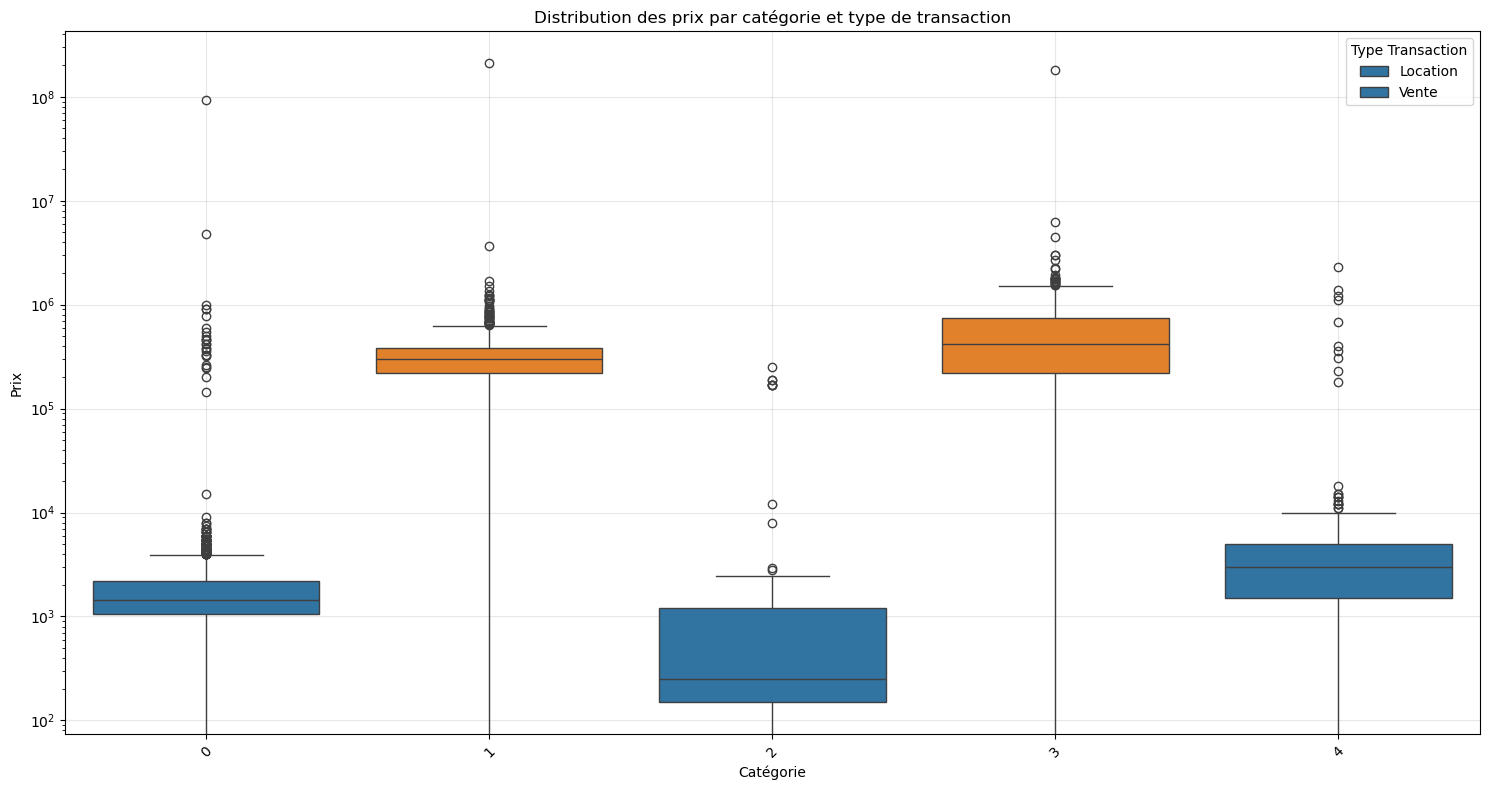

In [80]:
# Analyse des prix par type de transaction et catégorie
plt.figure(figsize=(15, 8))
sns.boxplot(x='category', y='price', hue='type_transaction', data=df)
plt.title('Distribution des prix par catégorie et type de transaction')
plt.xlabel('Catégorie')
plt.ylabel('Prix')
plt.yscale('log')
plt.legend(title='Type Transaction', labels=['Location', 'Vente'])
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#affiche la distribution des prix par catégorie et type de transaction

Top 15 des localisations les plus actives:
location
Hammamet Sud          593
La Marsa              466
Mrezga                439
Jardin De Carthage    312
La Soukra             281
Menzah                269
Aïn Zaghouan          255
Hammamet              250
Sahloul               229
Manar                 220
Sousse Jawhara        198
Ennasr                186
Les Berges Du Lac     165
Hammamet Centre       139
L'aouina              136
Name: count, dtype: int64


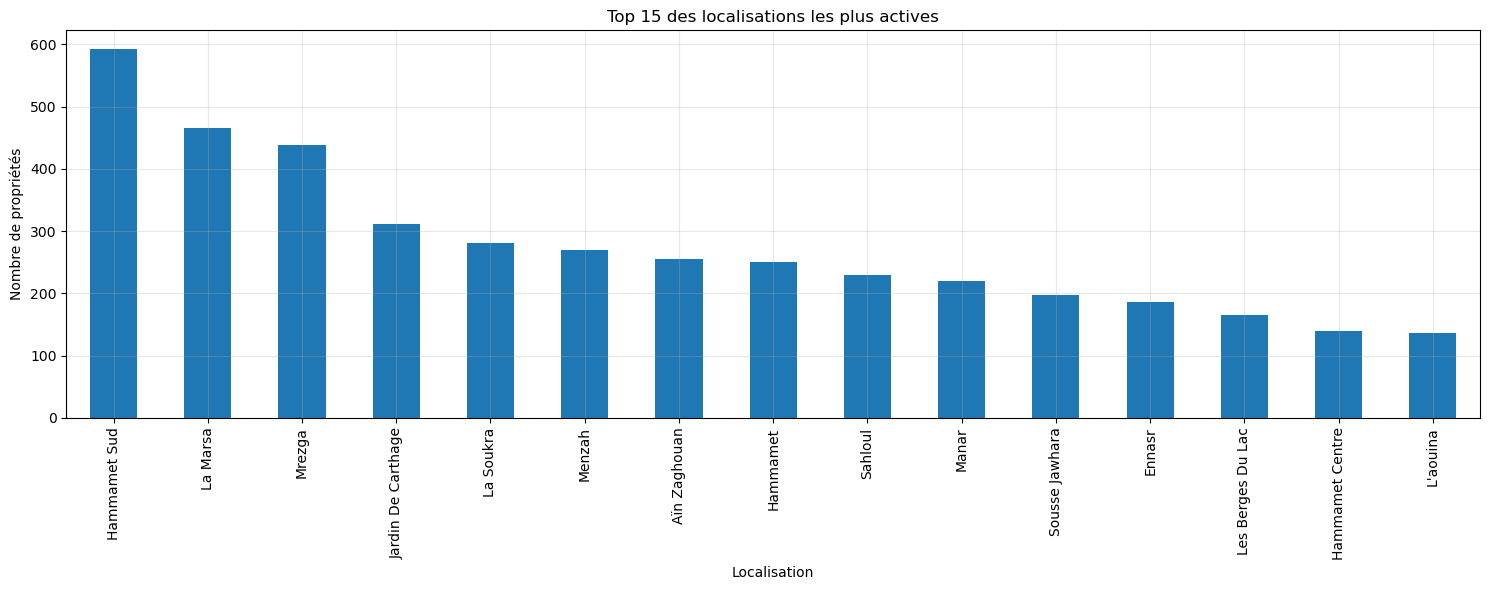

In [81]:
# Analyse des localisations les plus actives
location_counts = df['location'].value_counts().head(15)
print("Top 15 des localisations les plus actives:")
print(location_counts)

# Visualisation
plt.figure(figsize=(15, 6))
location_counts.plot(kind='bar')
plt.title('Top 15 des localisations les plus actives')
plt.xlabel('Localisation')
plt.ylabel('Nombre de propriétés')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

#affiche les localisations les plus actives

Prix moyen par localisation (avec au moins 5 propriétés) :
                         mean  count
location                            
Ennasr           2.142524e+06    186
Hammamet Sud     4.635056e+05    593
Manar            4.306408e+05    220
Chotrana         4.227250e+05      8
Béni Khiar       4.220122e+05     55
Hammamet         3.796490e+05    250
Kantaoui         3.356317e+05    105
Hammamet Centre  3.037284e+05    139
Akouda           2.973959e+05     88
Monastir         2.931146e+05     14
Raoued           2.895386e+05      7
Ghazela          2.797200e+05     25
Radès            2.404083e+05     12
Sousse Riadh     2.401842e+05     57
Nabeul           2.304591e+05    125


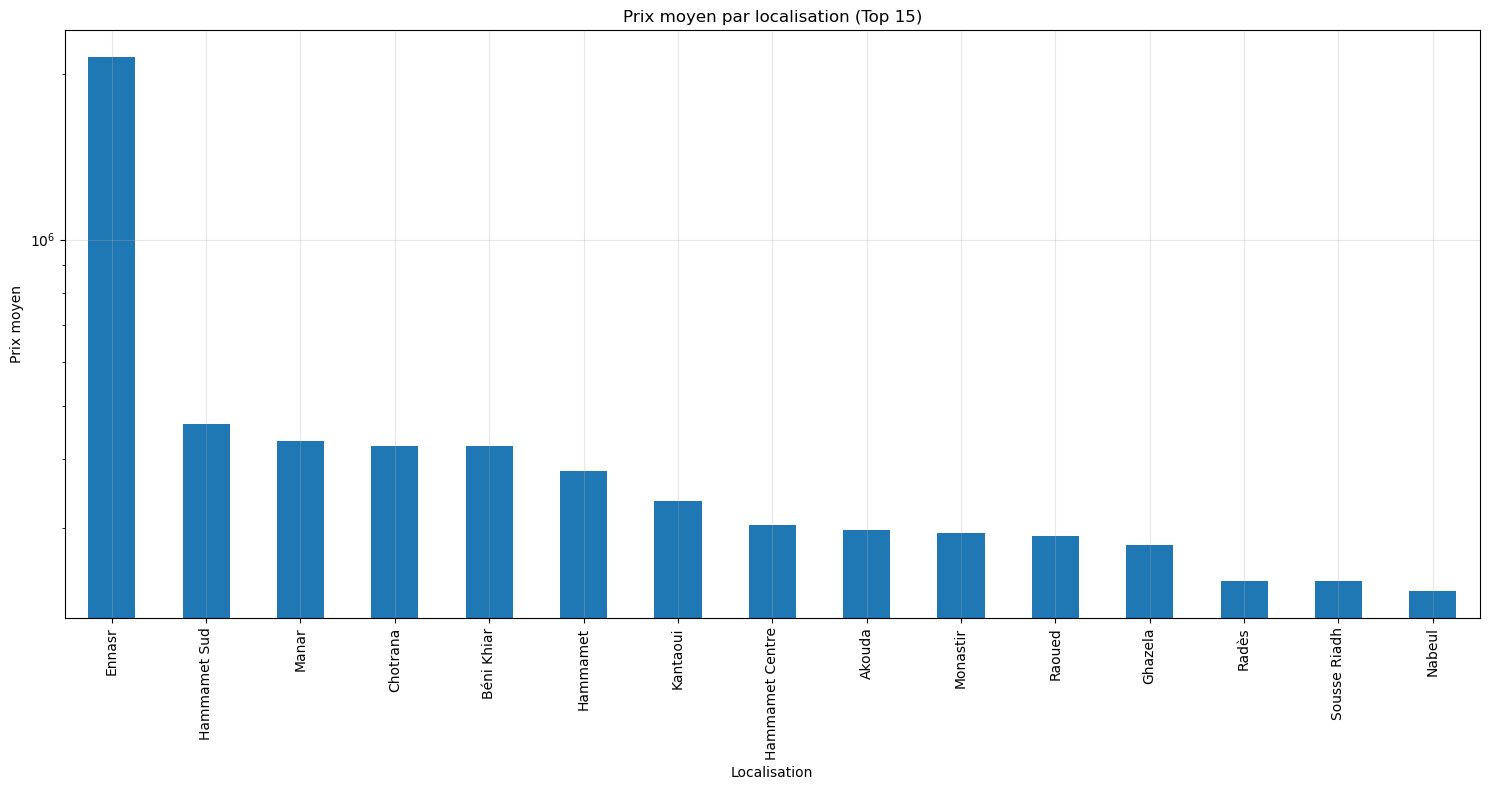

In [82]:
# Prix moyen par localisation (top 15)
prix_moyen_location = df.groupby('location')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Prix moyen par localisation (avec au moins 5 propriétés) :")
print(prix_moyen_location[prix_moyen_location['count'] >= 5].head(15).to_string())

# Visualisation
top_locations = prix_moyen_location[prix_moyen_location['count'] >= 5].head(15)
plt.figure(figsize=(15, 8))
top_locations['mean'].plot(kind='bar')
plt.title('Prix moyen par localisation (Top 15)')
plt.xlabel('Localisation')
plt.ylabel('Prix moyen')
plt.yscale('log')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

#affiche le prix moyen par localisation

In [83]:
# Analyse des caractéristiques les plus influentes sur le prix
from scipy.stats import pearsonr

# Corrélations avec le prix (uniquement pour les variables numériques)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('price')  # Retirer la cible

correlations = {}
for col in numeric_cols:
    if col != 'price':  # Éviter la corrélation avec elle-même
        corr, p_value = pearsonr(df[col], df['price'])
        correlations[col] = {'correlation': corr, 'p_value': p_value}

print("\nCorrélations avec le prix :")
for col, stats in sorted(correlations.items(), key=lambda x: abs(x[1]['correlation']), reverse=True):
    print(f"{col}: {stats['correlation']:.3f} (p-value: {stats['p_value']:.6f})")

#affiche les corrélations entre les caractéristiques numériques et le prix


Corrélations avec le prix :
type_transaction: 0.066 (p-value: 0.000001)
category: 0.025 (p-value: 0.065036)
post_year: -0.008 (p-value: 0.542879)
post_month: 0.000 (p-value: 0.999505)


In [84]:
# Résumé des insights clés
print("\n" + "="*60)
print("RÉSUMÉ DES INSIGHTS CLÉS DE L'ANALYSE EXPLORATOIRE")
print("="*60)
print(f"1. Dataset contient {len(df)} propriétés après nettoyage")
print(f"2. Prix moyen: {df['price'].mean():.0f} MAD (médiane: {df['price'].median():.0f} MAD)")
print(f"3. Gamme de prix: {df['price'].min():.0f} - {df['price'].max():.0f} MAD")
print(f"4. Types de transaction: {df['type_transaction'].value_counts().to_dict()}")
print(f"5. Catégories: {df['category'].value_counts().to_dict()}")
print(f"6. Villes couvertes: {df['city'].nunique()}")
print(f"7. Localisations couvertes: {df['location'].nunique()}")
print(f"8. Période des publications: {df['post_year'].min()} - {df['post_year'].max()}")

# Top caractéristiques corrélées avec le prix
if correlations:
    top_corr = sorted(correlations.items(), key=lambda x: abs(x[1]['correlation']), reverse=True)[:3]
    print(f"9. Top 3 caractéristiques corrélées avec le prix:")
    for col, stats in top_corr:
        print(f"   - {col}: {stats['correlation']:.3f}")

print("10. Les prix varient considérablement selon le type de transaction (location vs vente)")
print("11. Certaines localisations ont des prix significativement plus élevés")
print("12. La distribution des prix est très asymétrique, nécessitant une transformation")

#affiche un résumé des insights clés de l'analyse exploratoire


RÉSUMÉ DES INSIGHTS CLÉS DE L'ANALYSE EXPLORATOIRE
1. Dataset contient 5653 propriétés après nettoyage
2. Prix moyen: 260278 MAD (médiane: 3500 MAD)
3. Gamme de prix: 0 - 210000000 MAD
4. Types de transaction: {0: 3247, 1: 2406}
5. Catégories: {0: 2341, 1: 1431, 3: 975, 4: 697, 2: 209}
6. Villes couvertes: 12
7. Localisations couvertes: 85
8. Période des publications: 2025 - 2026
9. Top 3 caractéristiques corrélées avec le prix:
   - type_transaction: 0.066
   - category: 0.025
   - post_year: -0.008
10. Les prix varient considérablement selon le type de transaction (location vs vente)
11. Certaines localisations ont des prix significativement plus élevés
12. La distribution des prix est très asymétrique, nécessitant une transformation
